In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

In [7]:
df = pd.read_csv('../notebooks/WELFake_Dataset.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (72134, 4)

Columns: ['Unnamed: 0', 'title', 'text', 'label']


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [8]:
print("Total articles:", len(df))
print("\nClass distribution:")
print(df['label'].value_counts())
print("\nMissing values:")
print(df.isnull().sum())
print("\nAverage title length (words):", df['title'].dropna().apply(lambda x: len(x.split())).mean().round(2))
print("Average body length (words):", df['text'].dropna().apply(lambda x: len(x.split())).mean().round(2))

Total articles: 72134

Class distribution:
label
1    37106
0    35028
Name: count, dtype: int64

Missing values:
Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

Average title length (words): 12.27
Average body length (words): 540.84


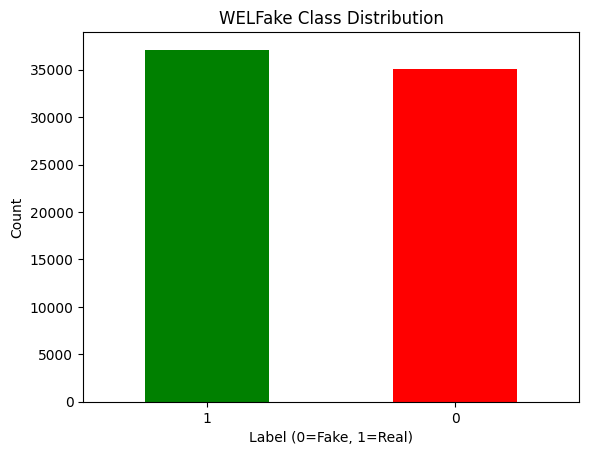

In [9]:
df['label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('WELFake Class Distribution')
plt.xlabel('Label (0=Fake, 1=Real)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [17]:
liar_train = pd.read_excel('../notebooks/liar/liar_data.xlsx', sheet_name='train')
liar_test = pd.read_excel('../notebooks/liar/liar_data.xlsx', sheet_name='test')
liar_val = pd.read_excel('../notebooks/liar/liar_data.xlsx', sheet_name='val')

print("LIAR dataset loaded!")
print("Train size:", len(liar_train))
print("Test size:", len(liar_test))
print("Val size:", len(liar_val))
print("\nColumns:", liar_train.columns.tolist())

LIAR dataset loaded!
Train size: 10269
Test size: 1283
Val size: 1284

Columns: ['ID', 'Label', 'Text', 'Subject', 'Speaker', 'Job', 'State', 'Party', 'BT', 'F', 'HT', 'MT', 'POF', 'Context']


LIAR label distribution:
Label
half-true      2123
False          1998
mostly-true    1966
True           1683
barely-true    1657
pants-fire      842
Name: count, dtype: int64


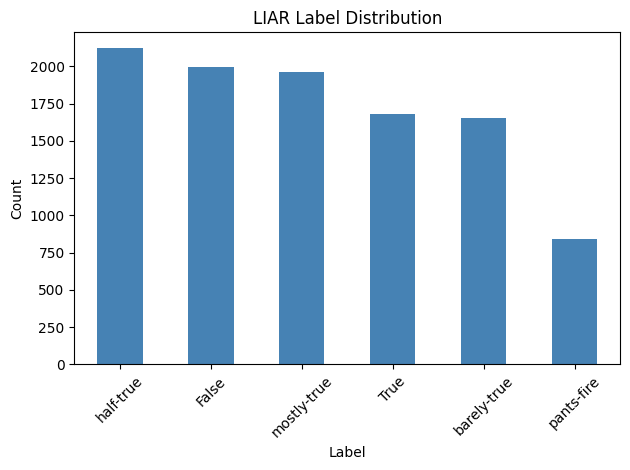

In [18]:
print("LIAR label distribution:")
print(liar_train['Label'].value_counts())

liar_train['Label'].value_counts().plot(kind='bar', color='steelblue')
plt.title('LIAR Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
print("""
ACCURACY TARGETS
================
Logistic Regression baseline (Step 3):  70-75% F1
DeBERTa-v3 on WELFake test split:       90%+   F1
DeBERTa-v3 cross-dataset on LIAR:       80%+   F1

LIAR LABEL MAPPING (6 → binary):
REAL (1): true, mostly-true, half-true
FAKE (0): false, barely-true, pants-fire
""")


ACCURACY TARGETS
Logistic Regression baseline (Step 3):  70-75% F1
DeBERTa-v3 on WELFake test split:       90%+   F1
DeBERTa-v3 cross-dataset on LIAR:       80%+   F1

LIAR LABEL MAPPING (6 → binary):
REAL (1): true, mostly-true, half-true
FAKE (0): false, barely-true, pants-fire

